In [643]:
import numpy as np 
import pandas as pd 
from tqdm import tqdm

# Load and filter data
round_slots = pd.read_csv("../data/MNCAATourneySlots.csv")
round_slots = round_slots[round_slots['Season'] == 2025]
round_slots = round_slots[round_slots['Slot'].str.contains('R')] # Filter out First Four


round_slots_w = pd.read_csv("../data/WNCAATourneySlots.csv")
round_slots_w = round_slots_w[round_slots_w['Season'] == 2025]
round_slots_w = round_slots_w[round_slots_w['Slot'].str.contains('R')] # Filter out First Four

# seeds = pd.read_csv("../data/MNCAATourneySeeds.csv")

seeds_m = pd.read_csv("../data/MNCAATourneySeeds.csv")
seeds_w = pd.read_csv("../data/WNCAATourneySeeds.csv")

seeds_m = seeds_m[seeds_m.Season == 2025]
seeds_w = seeds_w[seeds_w.Season == 2025]

seeds_m = seeds_m[~seeds_m['Seed'].str.endswith('b')]  # Remove rows where 'col' ends in 'a'
seeds_m['Seed'] = seeds_m['Seed'].str.rstrip('a')  # Remove trailing 'a' from remaining values

seeds_w = seeds_w[~seeds_w['Seed'].str.endswith('a')]  # Remove rows where 'col' ends in 'b'
seeds_w['Seed'] = seeds_w['Seed'].str.rstrip('b')  # Remove trailing 'a' from remaining values

# preds = pd.read_csv("../submissions/sub1_3_13.csv")
# preds = pd.read_csv("traditional_format_sub.csv")
preds_w = pd.read_csv("womens_sub_actual_games.csv")
# preds = pd.read_csv("submission_3_17_24.csv")
preds = pd.read_csv('sub_blended_3_17.csv')
# preds = pd.read_csv('submission_3_18_25_old_approach.csv')


preds['ID'] = preds['ID'].str.split('_')
preds["team1"] = preds["ID"].apply(lambda x: x[1])
preds["team2"] = preds["ID"].apply(lambda x: x[2])

preds_w['ID'] = preds_w['ID'].str.split('_')
preds_w["team1"] = preds_w["ID"].apply(lambda x: x[1])
preds_w["team2"] = preds_w["ID"].apply(lambda x: x[2])



In [644]:
preds

,ID,Old Pred,ID.1,New Pred,Pred,team1,team2
0,"[2025, 1103, 1104]",0.082287,2025_1103_1104,0.056663,0.066912,1103,1104
1,"[2025, 1103, 1106]",0.826624,2025_1103_1106,0.857163,0.844948,1103,1106
2,"[2025, 1103, 1110]",0.751808,2025_1103_1110,0.824579,0.795471,1103,1110
3,"[2025, 1103, 1112]",0.127289,2025_1103_1112,0.058031,0.085734,1103,1112
4,"[2025, 1103, 1116]",0.290064,2025_1103_1116,0.209297,0.241604,1103,1116
...,...,...,...,...,...,...,...
2269,"[2025, 1459, 1463]",0.271869,2025_1459_1463,0.392944,0.344514,1459,1463
2270,"[2025, 1459, 1471]",0.174098,2025_1459_1471,0.251822,0.220732,1459,1471
2271,"[2025, 1462, 1463]",0.567517,2025_1462_1463,0.753486,0.679098,1462,1463
2272,"[2025, 1462, 1471]",0.425564,2025_1462_1471,0.613803,0.538508,1462,1471


In [645]:
def prepare_data(seeds, preds):
    # Function preparing the data for the simulation
    seed_dict = seeds.set_index('Seed')['TeamID'].to_dict()
    inverted_seed_dict = {value: key for key, value in seed_dict.items()}
    probas_dict = {}
    
    for teams, proba in zip(preds['ID'], preds['Pred']):
        team1, team2 = teams[1], teams[2]

        probas_dict.setdefault(team1, {})[team2] = proba
        probas_dict.setdefault(team2, {})[team1] = 1 - proba

    return seed_dict, inverted_seed_dict, probas_dict


def simulate(round_slots, seeds, inverted_seeds, probas, sim=True):
    '''
    Simulates each round of the tournament.

    Parameters:
    - round_slots: DataFrame containing information on who is playing in each round.
    - seeds (dict): Dictionary mapping seed values to team IDs.
    - inverted_seeds (dict): Dictionary mapping team IDs to seed values.
    - probas (dict): Dictionary containing matchup probabilities.
    - sim (boolean): Simulates match if True. Chooses team with higher probability as winner otherwise.

    Returns:
    - list: List with winning team IDs for each match.
    - list: List with corresponding slot names for each match.
    '''

    winners = []
    slots = []

    for slot, strong, weak in zip(round_slots.Slot, round_slots.StrongSeed, round_slots.WeakSeed):
        team_1, team_2 = seeds[strong], seeds[weak]

        # Get the probability of team_1 winning
        proba = probas[str(team_1)][str(team_2)]
            
        if sim:
            # Randomly determine the winner based on the probability
            winner = np.random.choice([team_1, team_2], p=[proba, 1 - proba])
        else:
            # Determine the winner based on the higher probability
            winner = [team_1, team_2][np.argmax([proba, 1-proba])]
            
        # Append the winner and corresponding slot to the lists
        winners.append(winner)
        slots.append(slot)

        seeds[slot] = winner

    # Convert winners to original seeds using the inverted_seeds dictionary
    return [inverted_seeds[w] for w in winners], slots


def run_simulation(brackets=1, seeds=None, preds=None, round_slots=None, sim=True):
    '''
    Runs a simulation of bracket tournaments.

    Parameters:
    - brackets (int): Number of brackets to simulate.
    - seeds (pd.DataFrame): DataFrame containing seed information.
    - preds (pd.DataFrame): DataFrame containing prediction information for each match-up.
    - round_slots (pd.DataFrame): DataFrame containing information about the tournament rounds.
    - sim (boolean): Simulates matches if True. Chooses team with higher probability as winner otherwise.

    Returns:
    - pd.DataFrame: DataFrame with simulation results.
    '''
    # Get relevant data for the simulation
    seed_dict, inverted_seed_dict, probas_dict = prepare_data(seeds, preds)
    # Lists to store simulation results
    results = []
    bracket = []
    slots = []

    print(probas_dict)

    # Iterate through the specified number of brackets
    for b in tqdm(range(1, brackets+1)):
        # Run single simulation
        r, s = simulate(round_slots, seed_dict, inverted_seed_dict, probas_dict, sim)
        
        # Update results
        results.extend(r)
        bracket.extend([b] * len(r))
        slots.extend(s)

    # Create final DataFrame
    result_df = pd.DataFrame({'Bracket': bracket, 'Slot': slots, 'Team': results})

    return result_df


In [646]:
n_brackets = 10000
result_m=run_simulation(brackets=n_brackets, seeds=seeds_m, preds=preds, round_slots=round_slots, sim=True)
result_m['Tournament'] = 'M'

{'1103': {'1104': 0.0669124992263454, '1106': 0.8449475945754795, '1110': 0.7954706347244318, '1112': 0.0857342600476341, '1116': 0.2416037470969306, '1120': 0.0457769807085828, '1124': 0.1393713717733374, '1136': 0.5711952741195154, '1140': 0.1593275772016671, '1155': 0.1427367811213036, '1161': 0.2600810392838809, '1163': 0.1577770128017751, '1166': 0.1926397430844239, '1179': 0.265727605191315, '1181': 0.03452172920542, '1188': 0.7186081919301204, '1196': 0.0504617585013916, '1208': 0.2477487528263353, '1211': 0.0789187443271368, '1213': 0.4303090907286593, '1219': 0.3986837160003782, '1222': 0.0384604837945635, '1228': 0.1820663751674599, '1235': 0.1210460879409544, '1242': 0.1294890357598343, '1246': 0.1517880222572201, '1251': 0.2806888653075455, '1252': 0.4427243479219239, '1257': 0.1674042162804995, '1266': 0.180159652530556, '1268': 0.1137836374740541, '1270': 0.3721117179469181, '1272': 0.2932894522010929, '1276': 0.1831654699873349, '1277': 0.1171498092109575, '1279': 0.1902

100%|██████████| 10000/10000 [00:05<00:00, 1829.54it/s]


In [581]:
# n_brackets = 10000
# result_w=run_simulation(brackets=n_brackets, seeds=seeds_w, preds=preds_w, round_slots=round_slots, sim=True)
# result_w['Tournament'] = 'W'

In [647]:
# Add TeamID and name
m_seeds = pd.read_csv("../data/MNCAATourneySeeds.csv")[["Seed", "Season", "TeamID"]]
m_seeds = m_seeds[m_seeds.Season == 2025]
m_seeds = m_seeds[~m_seeds['Seed'].str.endswith('b')]  # Remove rows where 'col' ends in 'b'
m_seeds['Seed'] = m_seeds['Seed'].str.rstrip('a') 
m_seeds.columns = ["Team", "Season", "TeamID"]

result_m = result_m.merge(m_seeds, how="left", on="Team")
teams = pd.read_csv("../data/MTeams.csv")
teams["TeamID"] = teams["TeamID"].astype(float)
result_m = result_m.merge(teams, how="left", on="TeamID")
result_m["Round"] = result_m.Slot.str[1].astype(int)
result_m["Quadrant"] = result_m.Slot.str[2]



In [583]:
# # Add TeamID and name
# w_seeds = pd.read_csv("../data/WNCAATourneySeeds.csv")[["Seed", "Season", "TeamID"]]
# w_seeds = w_seeds[w_seeds.Season == 2025]
# w_seeds = w_seeds[~w_seeds['Seed'].str.endswith('b')]  # Remove rows where 'col' ends in 'b'
# w_seeds['Seed'] = w_seeds['Seed'].str.rstrip('a') 
# w_seeds.columns = ["Team", "Season", "TeamID"]
# result_w = result_w.merge(w_seeds, how="left", on="Team")
# teams = pd.read_csv("../data/WTeams.csv")
# teams["TeamID"] = teams["TeamID"].astype(float)
# result_w = result_w.merge(teams, how="left", on="TeamID")
# result_w["Round"] = result_w.Slot.str[1].astype(int)
# result_w["Quadrant"] = result_w.Slot.str[2]

In [584]:
# Y11, X11

### Sample charts

In [648]:
from matplotlib import pyplot as plt

def plot_likelihoods(sim_df, round, quadrant=None):

    sim_round_df = sim_df[sim_df.Round == round]

    if quadrant:
        sim_round_df = sim_round_df[sim_round_df.Quadrant == quadrant]

    sim_round_df_plot = pd.DataFrame(sim_round_df[["TeamName", "Team"]].value_counts())
    sim_round_df_plot = sim_round_df_plot.reset_index()

    sim_round_df_plot["Team Label"] = sim_round_df_plot['TeamName'] + " - " + sim_round_df_plot['Team']
    sim_round_df_plot["round"] = round

    fig, ax = plt.subplots(figsize=(20, 6))
    bar_container = ax.bar(sim_round_df_plot["Team Label"], sim_round_df_plot['count'])
    ax.bar_label(bar_container)
    ax.set_xticklabels(sim_round_df_plot["Team Label"], rotation=45)
    ax.tick_params(axis='x', rotation=45)

    return sim_round_df_plot


In [649]:
mapping_dict = {1:1, 2:2, 3:4, 4:8, 5:16, 6:32}

mapping_dict_espn = {1:10, 2:20, 3:40, 4:80, 5:160, 6:320}

mapping_dict_mike = {1:1, 2:2, 3:3, 4:4, 5:5, 6:6}


def get_ev(results_perc, mapping_dict=mapping_dict):
    results_perc['seed'] = results_perc["Team"].apply(lambda x: int(x[1:]))
    results_perc['prob'] = results_perc['count'] / 10000
    results_perc['value'] = results_perc['round'].map(mapping_dict)
    results_perc["ev"] = results_perc["value"] * results_perc["seed"] * results_perc["prob"]
    return results_perc.sort_values(by="ev", ascending=False)

def get_ev_espn(results_perc, mapping_dict=mapping_dict_espn):
    results_perc['seed'] = results_perc["Team"].apply(lambda x: int(x[1:]))
    results_perc['prob'] = results_perc['count'] / 10000
    results_perc['value'] = results_perc['round'].map(mapping_dict)
    results_perc["ev"] = results_perc["value"] * results_perc["prob"]
    return results_perc.sort_values(by="ev", ascending=False)

def get_ev_mike(results_perc, mapping_dict=mapping_dict_mike):
    results_perc['seed'] = results_perc["Team"].apply(lambda x: int(x[1:]))
    results_perc['prob'] = results_perc['count'] / 10000
    results_perc['value'] = results_perc['round'].map(mapping_dict)
    results_perc["ev"] = results_perc["value"] * results_perc["prob"]
    return results_perc.sort_values(by="ev", ascending=False)

def get_ev_dylan(results_perc, mapping_dict=mapping_dict):
    results_perc['seed'] = results_perc["Team"].apply(lambda x: int(x[1:]))
    results_perc['prob'] = results_perc['count'] / 10000
    results_perc['value'] = results_perc['round'].map(mapping_dict)
    results_perc["ev"] = (results_perc["value"] + results_perc["seed"]) * results_perc["prob"] 
    return results_perc.sort_values(by="ev", ascending=False)


/var/folders/h5/f91pbgmj0rj6v0ls3y8zc5l40000gn/T/ipykernel_23989/1129900088.py:19: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(sim_round_df_plot["Team Label"], rotation=45)


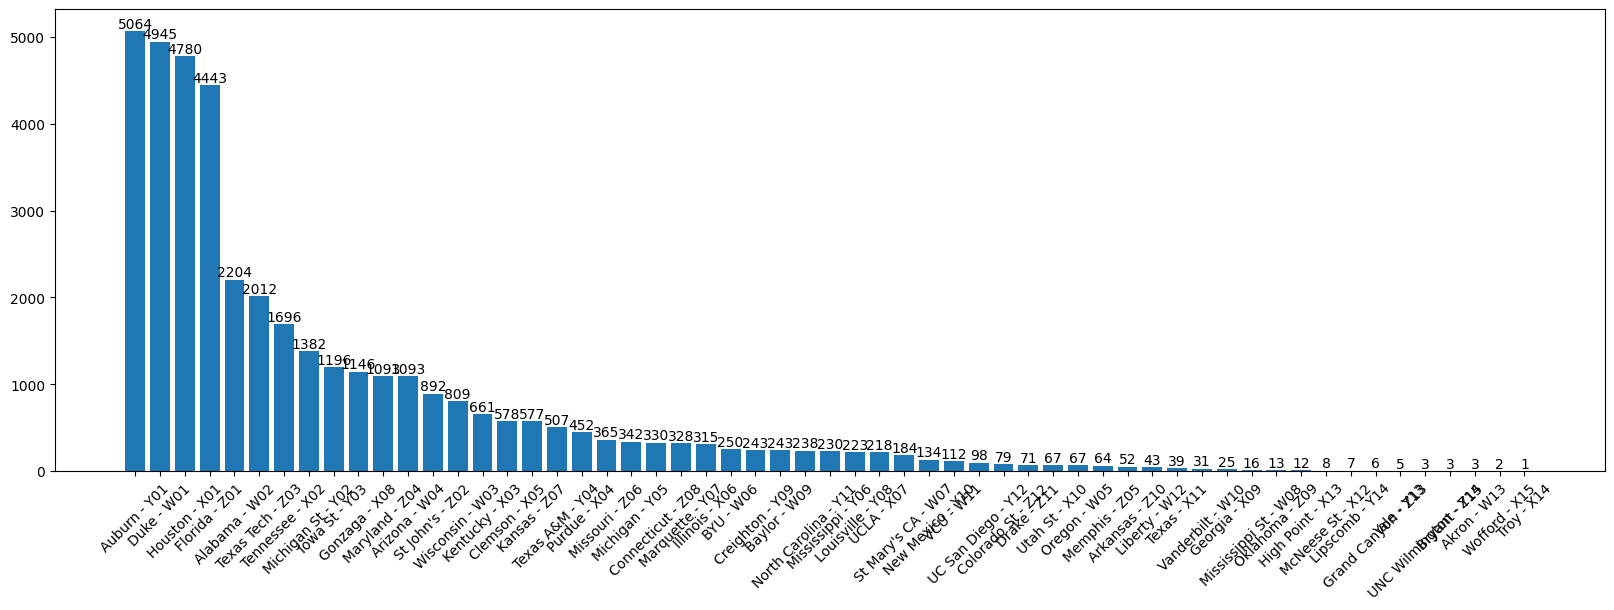

In [674]:
results_perc = plot_likelihoods(result_m, round=4)

In [675]:
results_perc["odds"] = results_perc["count"] / 10000 

In [676]:
results_perc

,TeamName,Team,count,Team Label,round,odds
0,Auburn,Y01,5064,Auburn - Y01,4,0.5064
1,Duke,W01,4945,Duke - W01,4,0.4945
2,Houston,X01,4780,Houston - X01,4,0.4780
3,Florida,Z01,4443,Florida - Z01,4,0.4443
4,Alabama,W02,2204,Alabama - W02,4,0.2204
5,Texas Tech,Z03,2012,Texas Tech - Z03,4,0.2012
6,Tennessee,X02,1696,Tennessee - X02,4,0.1696
7,Michigan St,Y02,1382,Michigan St - Y02,4,0.1382
8,Iowa St,Y03,1196,Iowa St - Y03,4,0.1196
9,Gonzaga,X08,1146,Gonzaga - X08,4,0.1146


In [667]:
# sorted(results_perc.Team.unique())

In [677]:
results_perc = get_ev(results_perc)

In [678]:
results_perc.head(60)


,TeamName,Team,count,Team Label,round,odds,seed,prob,value,ev
9,Gonzaga,X08,1146,Gonzaga - X08,4,0.1146,8,0.1146,8,7.3344
5,Texas Tech,Z03,2012,Texas Tech - Z03,4,0.2012,3,0.2012,8,4.8288
0,Auburn,Y01,5064,Auburn - Y01,4,0.5064,1,0.5064,8,4.0512
1,Duke,W01,4945,Duke - W01,4,0.4945,1,0.4945,8,3.9560
2,Houston,X01,4780,Houston - X01,4,0.4780,1,0.4780,8,3.8240
3,Florida,Z01,4443,Florida - Z01,4,0.4443,1,0.4443,8,3.5544
4,Alabama,W02,2204,Alabama - W02,4,0.2204,2,0.2204,8,3.5264
10,Maryland,Z04,1093,Maryland - Z04,4,0.1093,4,0.1093,8,3.4976
11,Arizona,W04,1093,Arizona - W04,4,0.1093,4,0.1093,8,3.4976
16,Kansas,Z07,577,Kansas - Z07,4,0.0577,7,0.0577,8,3.2312


/var/folders/h5/f91pbgmj0rj6v0ls3y8zc5l40000gn/T/ipykernel_23989/1129900088.py:19: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(sim_round_df_plot["Team Label"], rotation=45)


,TeamName,Team,count,Team Label,round
0,Houston,X01,5945,Houston - X01,4
1,Gonzaga,X08,1172,Gonzaga - X08,4
2,Tennessee,X02,935,Tennessee - X02,4
3,Clemson,X05,642,Clemson - X05,4
4,Kentucky,X03,428,Kentucky - X03,4
5,Illinois,X06,236,Illinois - X06,4
6,Purdue,X04,221,Purdue - X04,4
7,UCLA,X07,193,UCLA - X07,4
8,Xavier,X11,135,Xavier - X11,4
9,Utah St,X10,71,Utah St - X10,4


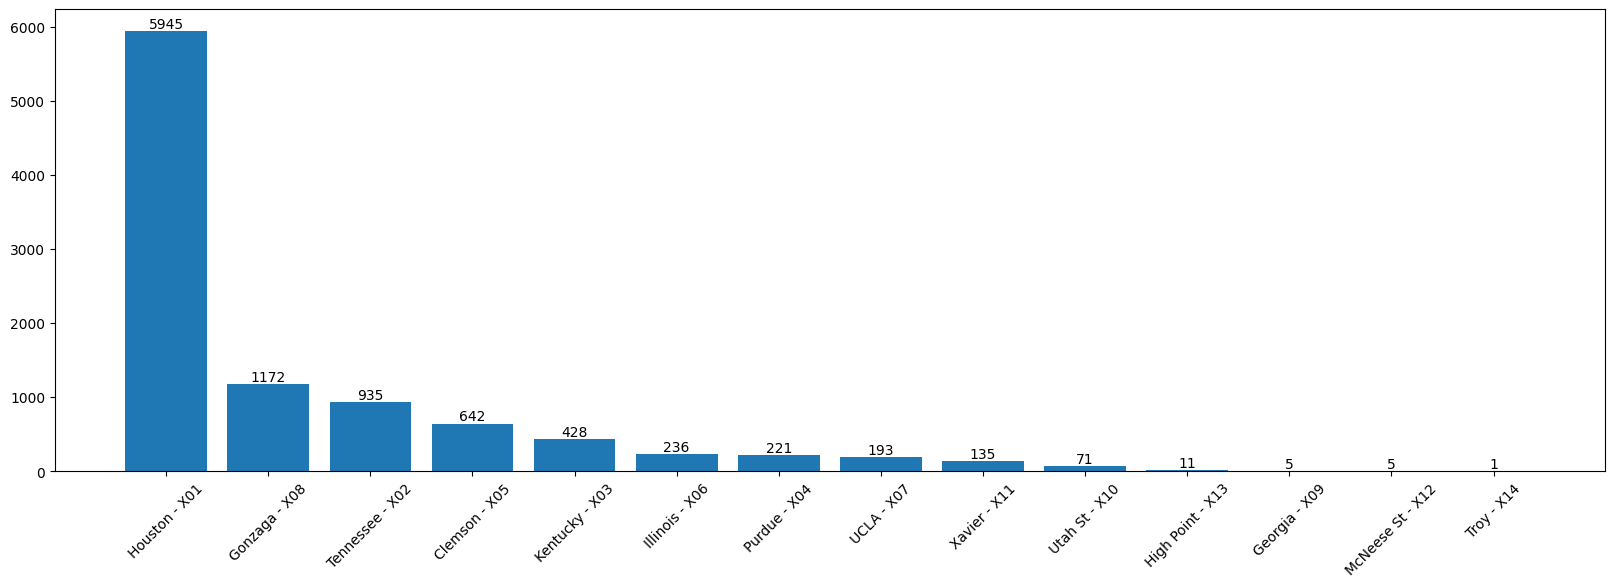

In [493]:
plot_likelihoods(result_m, round=4, quadrant="X")

/var/folders/h5/f91pbgmj0rj6v0ls3y8zc5l40000gn/T/ipykernel_23989/1129900088.py:19: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(sim_round_df_plot["Team Label"], rotation=45)


,TeamName,Team,count,Team Label,round
0,Auburn,Y01,7432,Auburn - Y01,2
1,Michigan St,Y02,5583,Michigan St - Y02,2
2,Iowa St,Y03,5382,Iowa St - Y03,2
3,Texas A&M,Y04,4589,Texas A&M - Y04,2
4,Michigan,Y05,3572,Michigan - Y05,2
5,Mississippi,Y06,3369,Mississippi - Y06,2
6,Marquette,Y07,2426,Marquette - Y07,2
7,New Mexico,Y10,1758,New Mexico - Y10,2
8,Creighton,Y09,1714,Creighton - Y09,2
9,UC San Diego,Y12,1432,UC San Diego - Y12,2


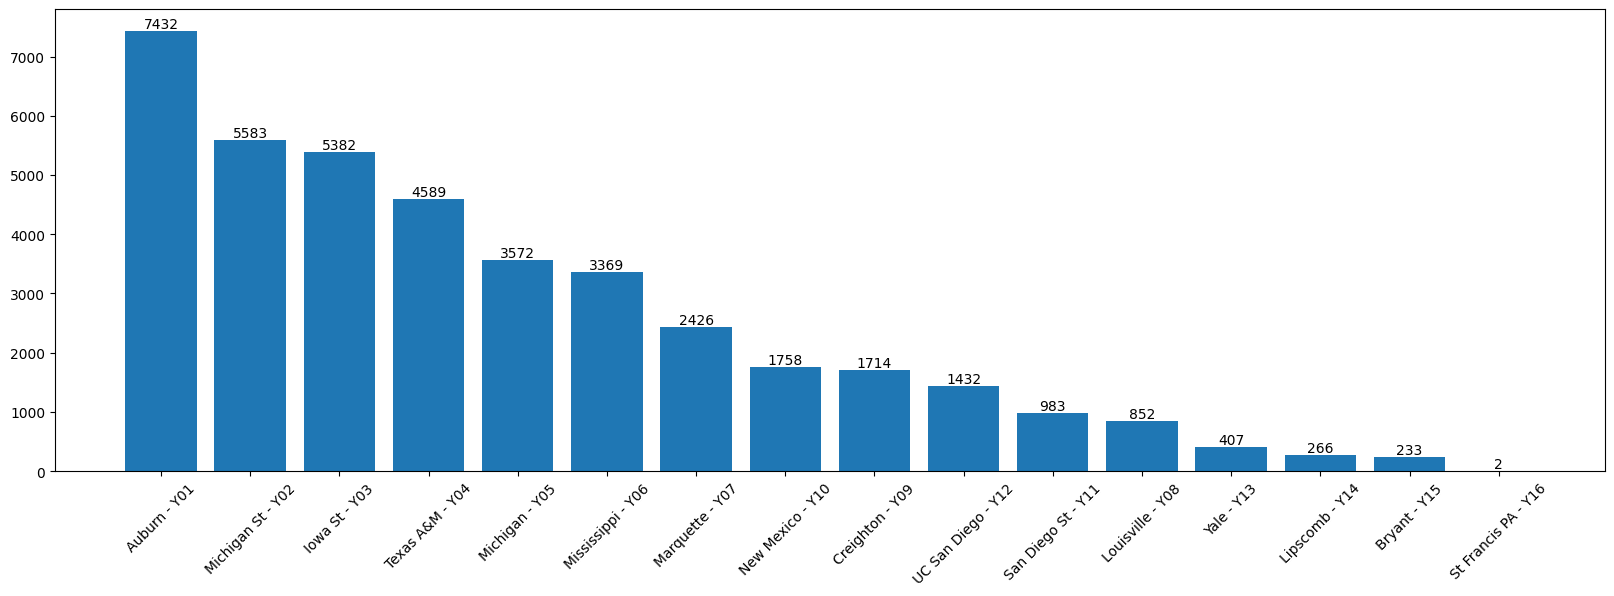

In [494]:
plot_likelihoods(result_m, round=2, quadrant="Y")

/var/folders/h5/f91pbgmj0rj6v0ls3y8zc5l40000gn/T/ipykernel_23989/1129900088.py:19: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(sim_round_df_plot["Team Label"], rotation=45)


,TeamName,Team,count,Team Label,round
0,Florida,Z01,8415,Florida - Z01,2
1,Texas Tech,Z03,6839,Texas Tech - Z03,2
2,Maryland,Z04,6714,Maryland - Z04,2
3,St John's,Z02,5439,St John's - Z02,2
4,Kansas,Z07,3660,Kansas - Z07,2
5,Colorado St,Z12,1835,Colorado St - Z12,2
6,Missouri,Z06,1737,Missouri - Z06,2
7,Connecticut,Z08,1372,Connecticut - Z08,2
8,Drake,Z11,1248,Drake - Z11,2
9,Memphis,Z05,909,Memphis - Z05,2


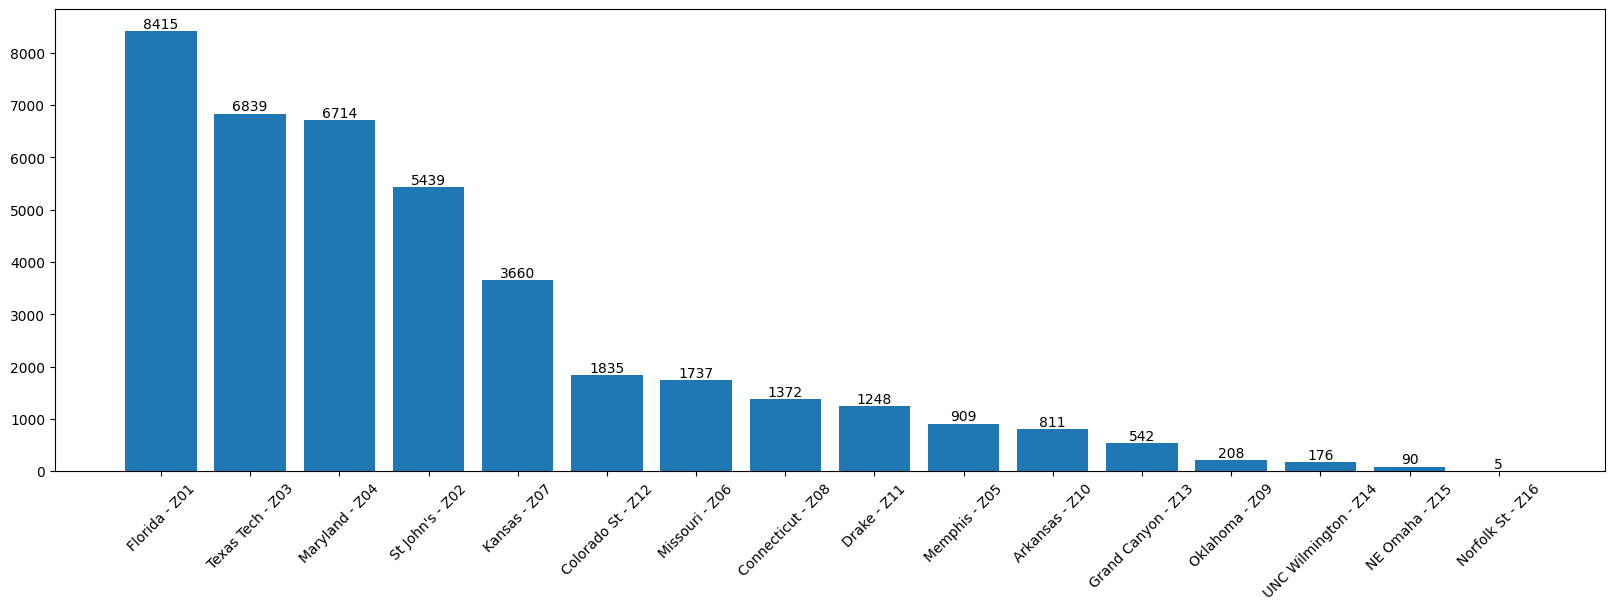

In [495]:
plot_likelihoods(result_m, round=2, quadrant="Z")

/var/folders/h5/f91pbgmj0rj6v0ls3y8zc5l40000gn/T/ipykernel_23989/1129900088.py:19: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(sim_round_df_plot["Team Label"], rotation=45)


,TeamName,Team,count,Team Label,round
0,Duke,W01,8244,Duke - W01,2
1,Alabama,W02,7463,Alabama - W02,2
2,Arizona,W04,6991,Arizona - W04,2
3,Wisconsin,W03,5910,Wisconsin - W03,2
4,BYU,W06,2567,BYU - W06,2
5,St Mary's CA,W07,1975,St Mary's CA - W07,2
6,Baylor,W09,1640,Baylor - W09,2
7,Liberty,W12,1574,Liberty - W12,2
8,VCU,W11,1473,VCU - W11,2
9,Oregon,W05,1342,Oregon - W05,2


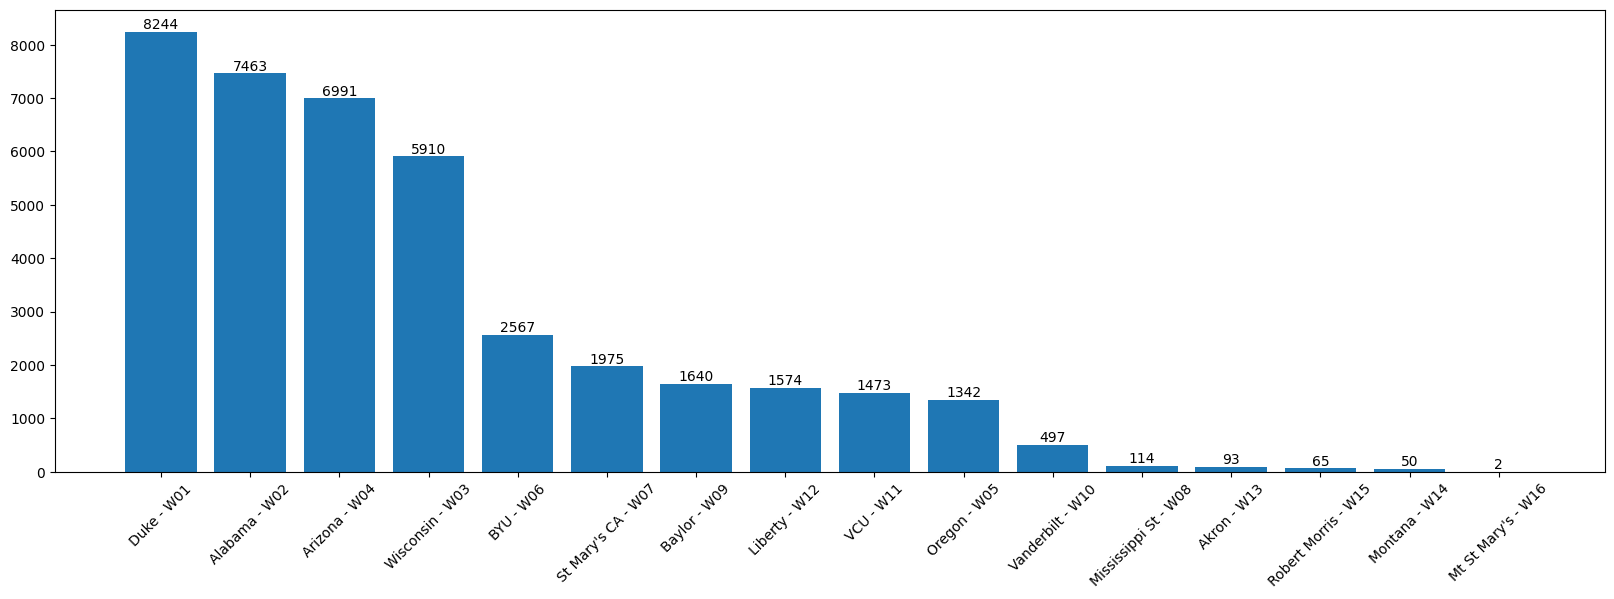

In [496]:
plot_likelihoods(result_m, round=2, quadrant="W")

/var/folders/h5/f91pbgmj0rj6v0ls3y8zc5l40000gn/T/ipykernel_23989/1129900088.py:19: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(sim_round_df_plot["Team Label"], rotation=45)


,TeamName,Team,count,Team Label,round
0,Houston,X01,5945,Houston - X01,4
1,Duke,W01,4795,Duke - W01,4
2,Florida,Z01,4699,Florida - Z01,4
3,Auburn,Y01,4267,Auburn - Y01,4
4,Texas Tech,Z03,2259,Texas Tech - Z03,4
5,Alabama,W02,1986,Alabama - W02,4
6,Michigan St,Y02,1638,Michigan St - Y02,4
7,Maryland,Z04,1203,Maryland - Z04,4
8,Gonzaga,X08,1172,Gonzaga - X08,4
9,Arizona,W04,1142,Arizona - W04,4


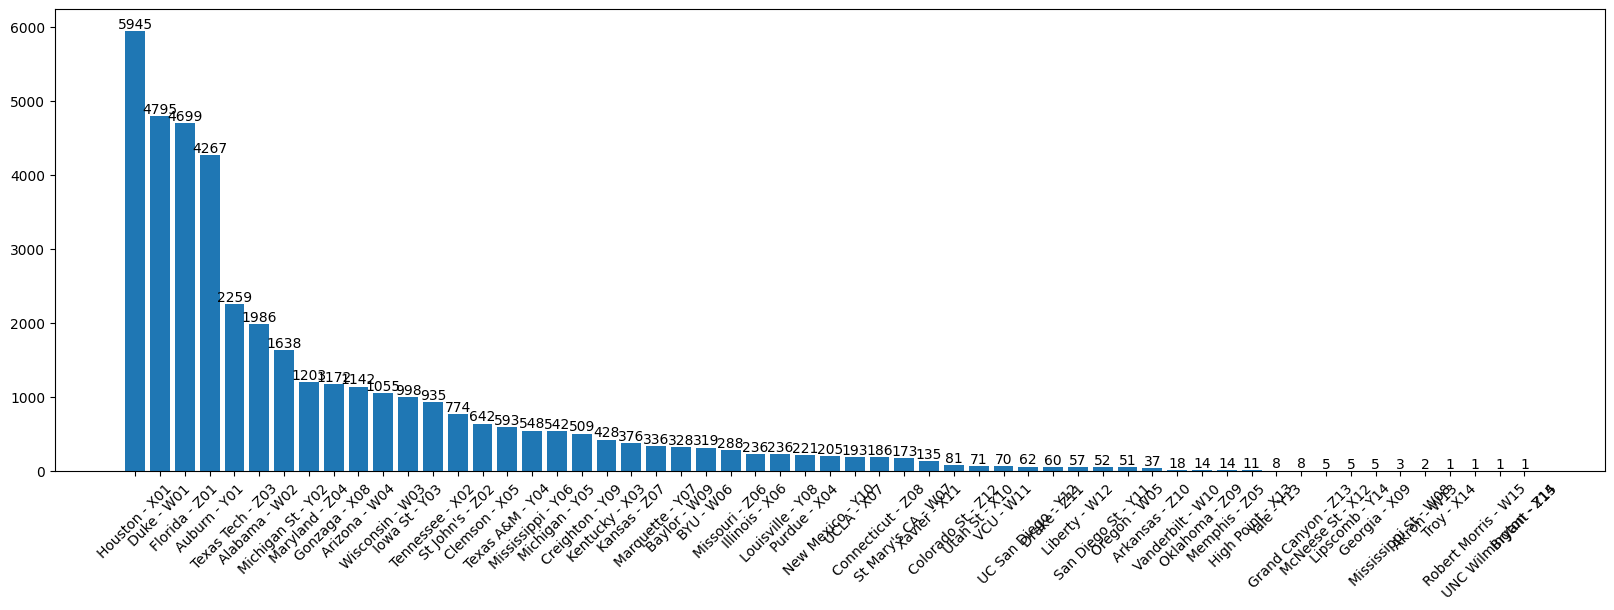

In [497]:
plot_likelihoods(result_m, round=4)

/var/folders/h5/f91pbgmj0rj6v0ls3y8zc5l40000gn/T/ipykernel_21878/3942773803.py:16: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(sim_round_df_plot['TeamName'], rotation=45)


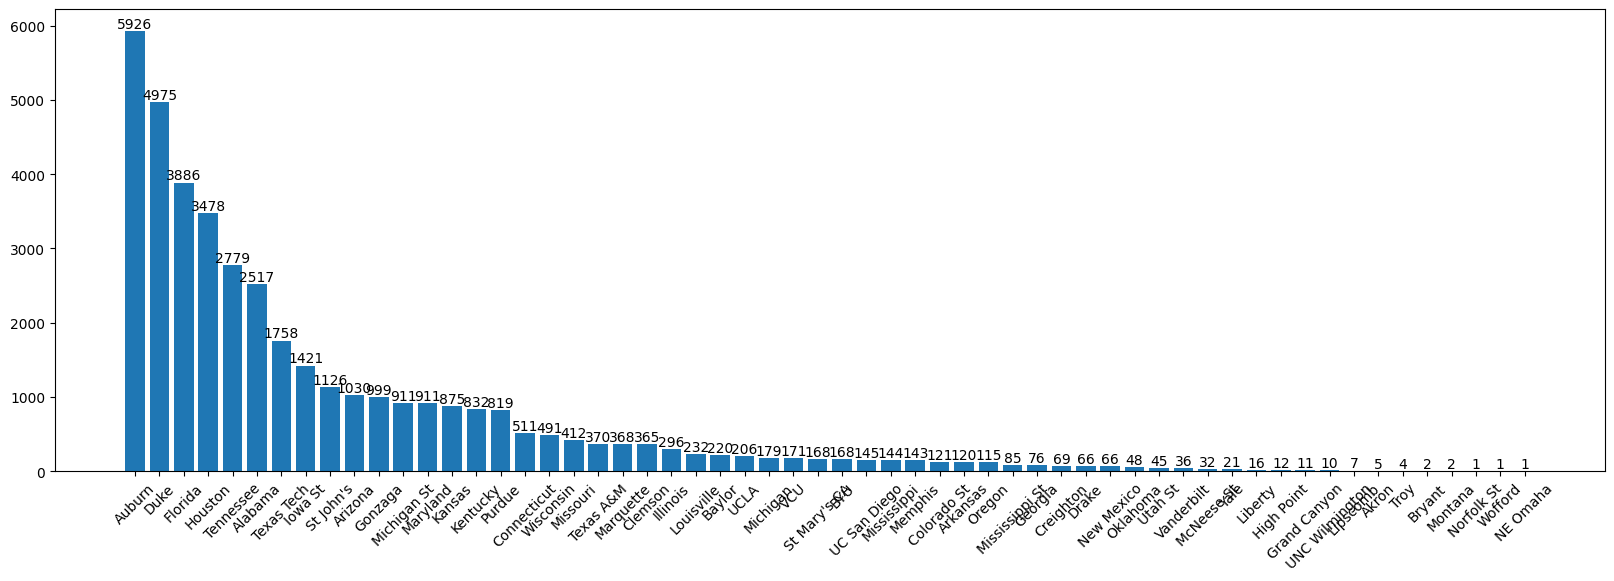

In [8]:
plot_likelihoods(result_m, round=4)

In [14]:
result_m.Quadrant.unique()

array(['W', 'X', 'Y', 'Z', 'C'], dtype=object)

/var/folders/h5/f91pbgmj0rj6v0ls3y8zc5l40000gn/T/ipykernel_23212/3942773803.py:16: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(sim_round_df_plot['TeamName'], rotation=45)


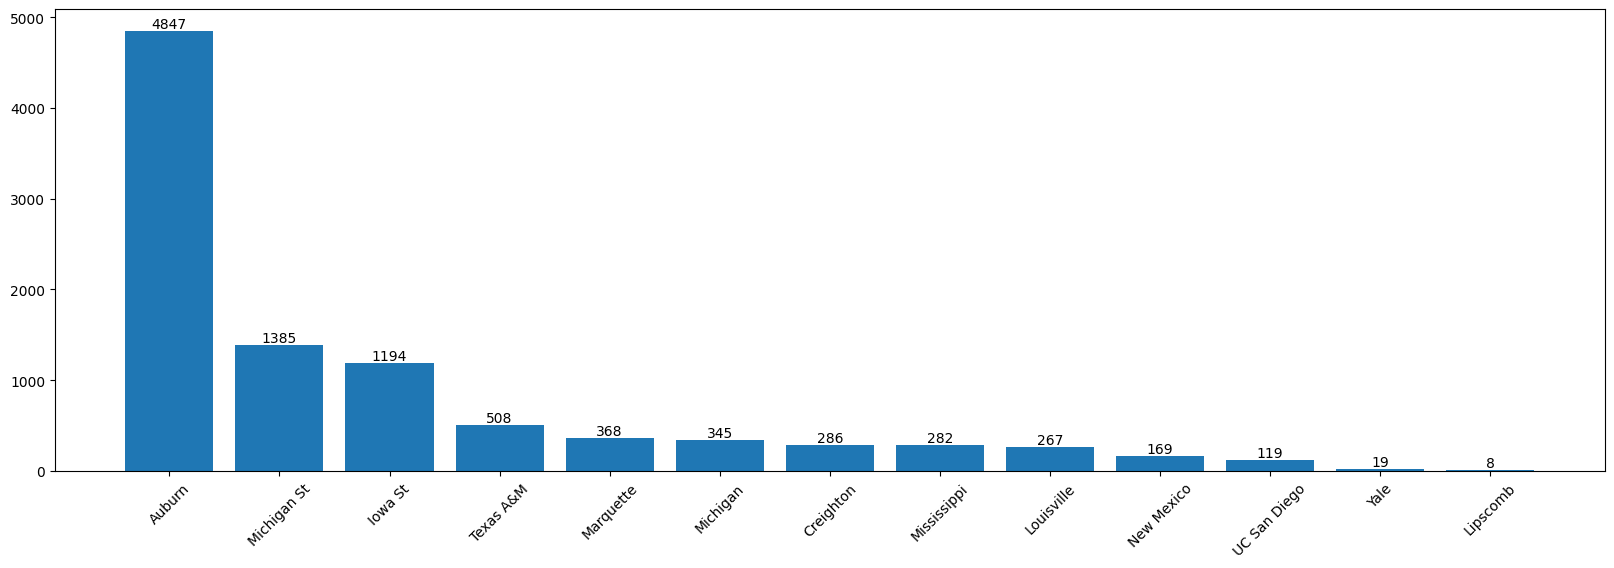

In [15]:
plot_likelihoods(result_m, round=4, quadrant="Y")

/var/folders/h5/f91pbgmj0rj6v0ls3y8zc5l40000gn/T/ipykernel_17834/3942773803.py:16: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(sim_round_df_plot['TeamName'], rotation=45)


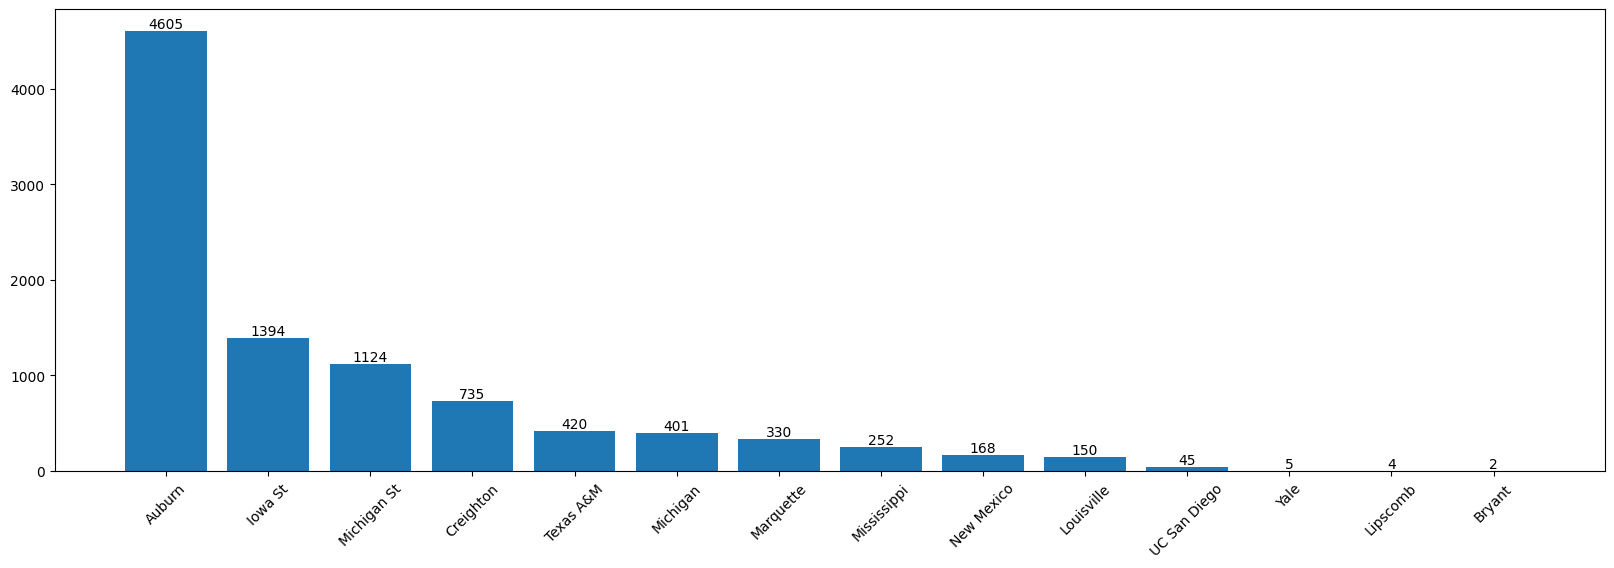

In [14]:
plot_likelihoods(result_m, round=4, quadrant="Y")

/var/folders/h5/f91pbgmj0rj6v0ls3y8zc5l40000gn/T/ipykernel_17834/3942773803.py:16: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(sim_round_df_plot['TeamName'], rotation=45)


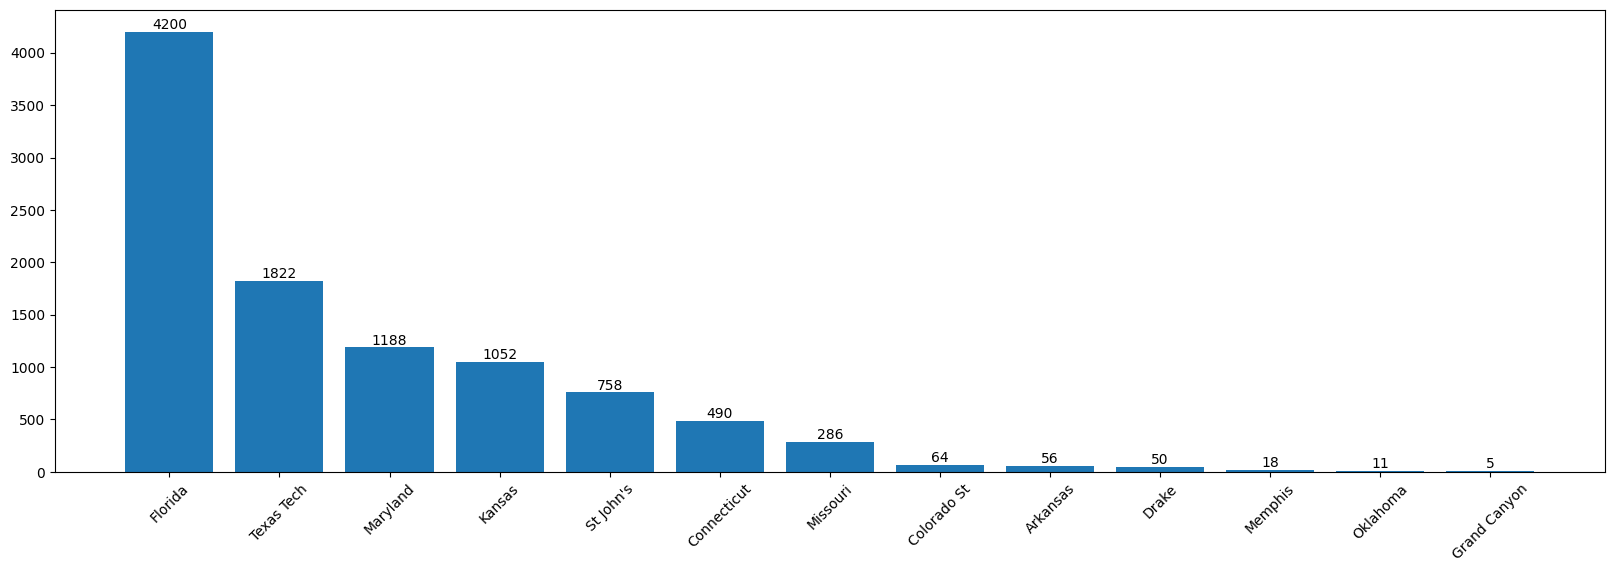

In [15]:
plot_likelihoods(result_m, round=4, quadrant="Z")

/var/folders/h5/f91pbgmj0rj6v0ls3y8zc5l40000gn/T/ipykernel_17834/3942773803.py:16: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(sim_round_df_plot['TeamName'], rotation=45)


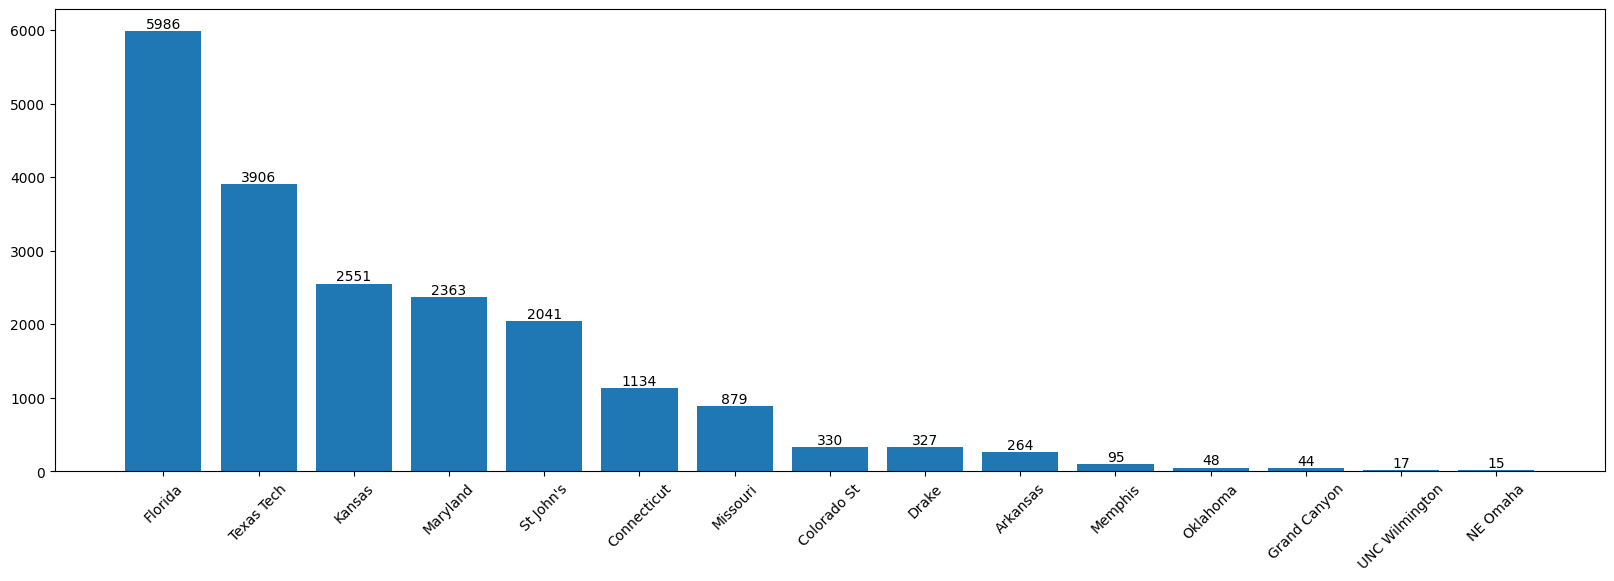

In [20]:
plot_likelihoods(result_m, round=3, quadrant="Z")

In [38]:
preds

,Unnamed: 0,ID,Pred,team1,team2
0,1319,"[2024, 1112, 1253]",0.981720,1112,1253
1,1320,"[2024, 1166, 1103]",0.902207,1166,1103
2,1321,"[2024, 1173, 1305]",0.377529,1173,1305
3,1322,"[2024, 1182, 1140]",0.278729,1182,1140
4,1323,"[2024, 1211, 1270]",0.921339,1211,1270
...,...,...,...,...,...
2271,1783,"[2024, 3425, 3163]",0.271958,3425,3163
2272,1784,"[2024, 3261, 3234]",0.358670,3261,3234
2273,1785,"[2024, 3163, 3234]",0.561212,3163,3234
2274,1786,"[2024, 3301, 3376]",0.128575,3301,3376


In [16]:
preds[['Seson', 'Team1', 'Team2']] = pd.DataFrame(preds['ID'].tolist(), columns=['Seson', 'Team1', 'Team2'])

In [17]:
teams = pd.read_csv("../data/MTeams.csv")
teams["TeamID"] = teams["TeamID"].astype(str)

teams1 = teams.copy()
teams2 = teams.copy()
teams1.columns = ["Team1", "team1_name", "x", "y"]
teams2.columns = ["Team2", "team2_name", "x", "y"]
teams1=teams1[["Team1", "team1_name"]]
teams2=teams2[["Team2", "team2_name"]]


preds = preds.merge(teams1, on="Team1").merge(teams2, on="Team2")


In [62]:
def game_lookup(df, t1, t2, features = ['ID', 'Team1_name', 'Team2_name', 'Pred'], season = 2021):

    t1 = t1.lower()
    t2 = t2.lower()
    
    return df[ 
        
        ((df.team1_name.str.lower().str.startswith(t1)) & 
                         (df.team2_name.str.lower().str.startswith(t2)) )

        |
        
        ((df.team1_name.str.lower().str.startswith(t2)) & 
                         (df.team2_name.str.lower().str.startswith(t1)) )
                         
                         ][features]
 

In [65]:
game_lookup(preds, 'St John', 'Florida', features = ['ID', 'team1_name', 'team2_name', 'Pred'], season = 2025)

,ID,team1_name,team2_name,Pred
1053,"[2025, 1196, 1385]",Florida,St John's,0.752179


In [59]:
preds[preds.team2_name == "St John's"]

,Unnamed: 0,ID,Pred,team1,team2,Seson,Team1,Team2,team1_name,team2_name
30,54202,"[2025, 1303, 1385]",0.093954,1303,1385,2025,1303,1385,NE Omaha,St John's
85,3757,"[2025, 1103, 1385]",0.110892,1103,1385,2025,1103,1385,Akron,St John's
150,4117,"[2025, 1104, 1385]",0.723608,1104,1385,2025,1104,1385,Alabama,St John's
213,4834,"[2025, 1106, 1385]",0.026276,1106,1385,2025,1106,1385,Alabama St,St John's
275,5902,"[2025, 1110, 1385]",0.030345,1110,1385,2025,1110,1385,American Univ,St John's
338,6609,"[2025, 1112, 1385]",0.628335,1112,1385,2025,1112,1385,Arizona,St John's
399,8011,"[2025, 1116, 1385]",0.328906,1116,1385,2025,1116,1385,Arkansas,St John's
459,9052,"[2025, 1120, 1385]",0.712482,1120,1385,2025,1120,1385,Auburn,St John's
518,10084,"[2025, 1124, 1385]",0.523828,1124,1385,2025,1124,1385,Baylor,St John's
576,13459,"[2025, 1136, 1385]",0.089502,1136,1385,2025,1136,1385,Bryant,St John's


In [18]:
preds[(preds.team1_name == "Colorado St")
      & (preds.team2_name == "Purdue")]


,Unnamed: 0,ID,Pred,team1,team2,Seson,Team1,Team2,team1_name,team2_name
794,21728,"[2025, 1163, 1345]",0.607187,1163,1345,2025,1163,1345,Connecticut,Purdue
